In [1]:
import numpy as np
import pandas as pd
import scanpy as sc



In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

/home/saif/miniconda3/envs/scanpy/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.10.3 anndata==0.10.9 umap==0.5.8 numpy==2.0.2 scipy==1.13.1 pandas==2.3.0+4.g1dfc98e16a scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.9 pynndescent==0.5.13


In [3]:
results_file = 'results/pbmc3k.h5ad'

In [5]:
adata = sc.read_10x_mtx(
    '/media/saif/New Volume1/Single-cellRNA-seq Analysis/Scanpy-scRNA-seq-Analysis/Gene-cell matrix Data',  # the directory with the `.mtx` file
    var_names='gene_symbols',                # use gene symbols for the variable names (variables-axis index)
    cache=True)                              # write a cache file for faster subsequent reading

... writing an h5ad cache file to speedup reading next time


In [6]:
adata.var_names_make_unique()

In [7]:
adata


AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

<b> **Preprocessing:** </b>

normalizing counts per cell
    finished (0:00:00)


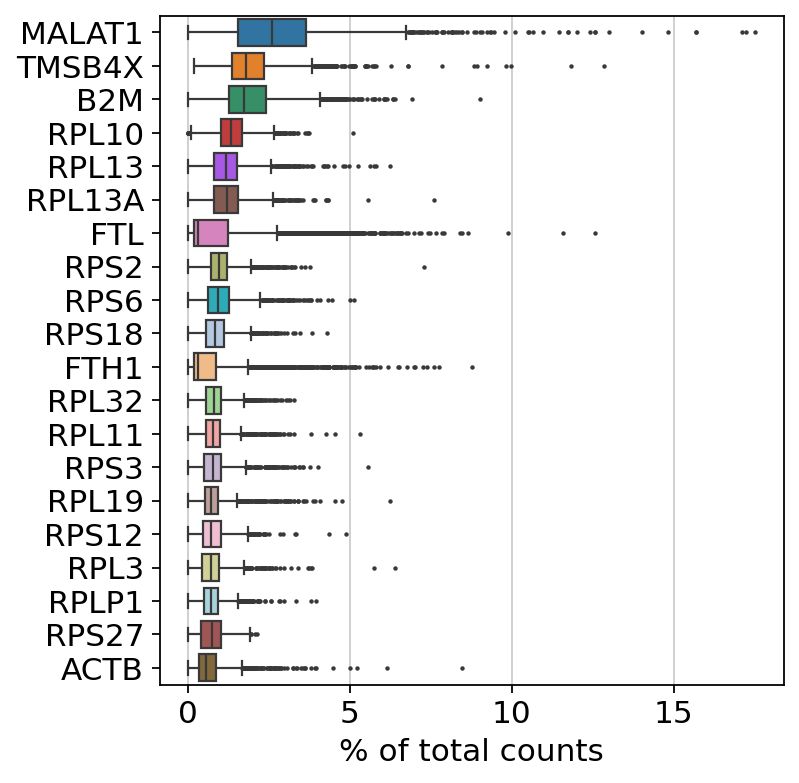

In [8]:
sc.pl.highest_expr_genes(adata, n_top=20)

Filtering:

In [9]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

filtered out 19024 genes that are detected in less than 3 cells


In [10]:
#mitochondrial genes filtering
adata.var['mt'] = adata.var_names.str.startswith ('MT-')
sc.pp.calculate_qc_metrics (adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True )

violin plot/cal:
     1.n_genes_by_counts
    2.total_counts
     3.pct_counts_mt


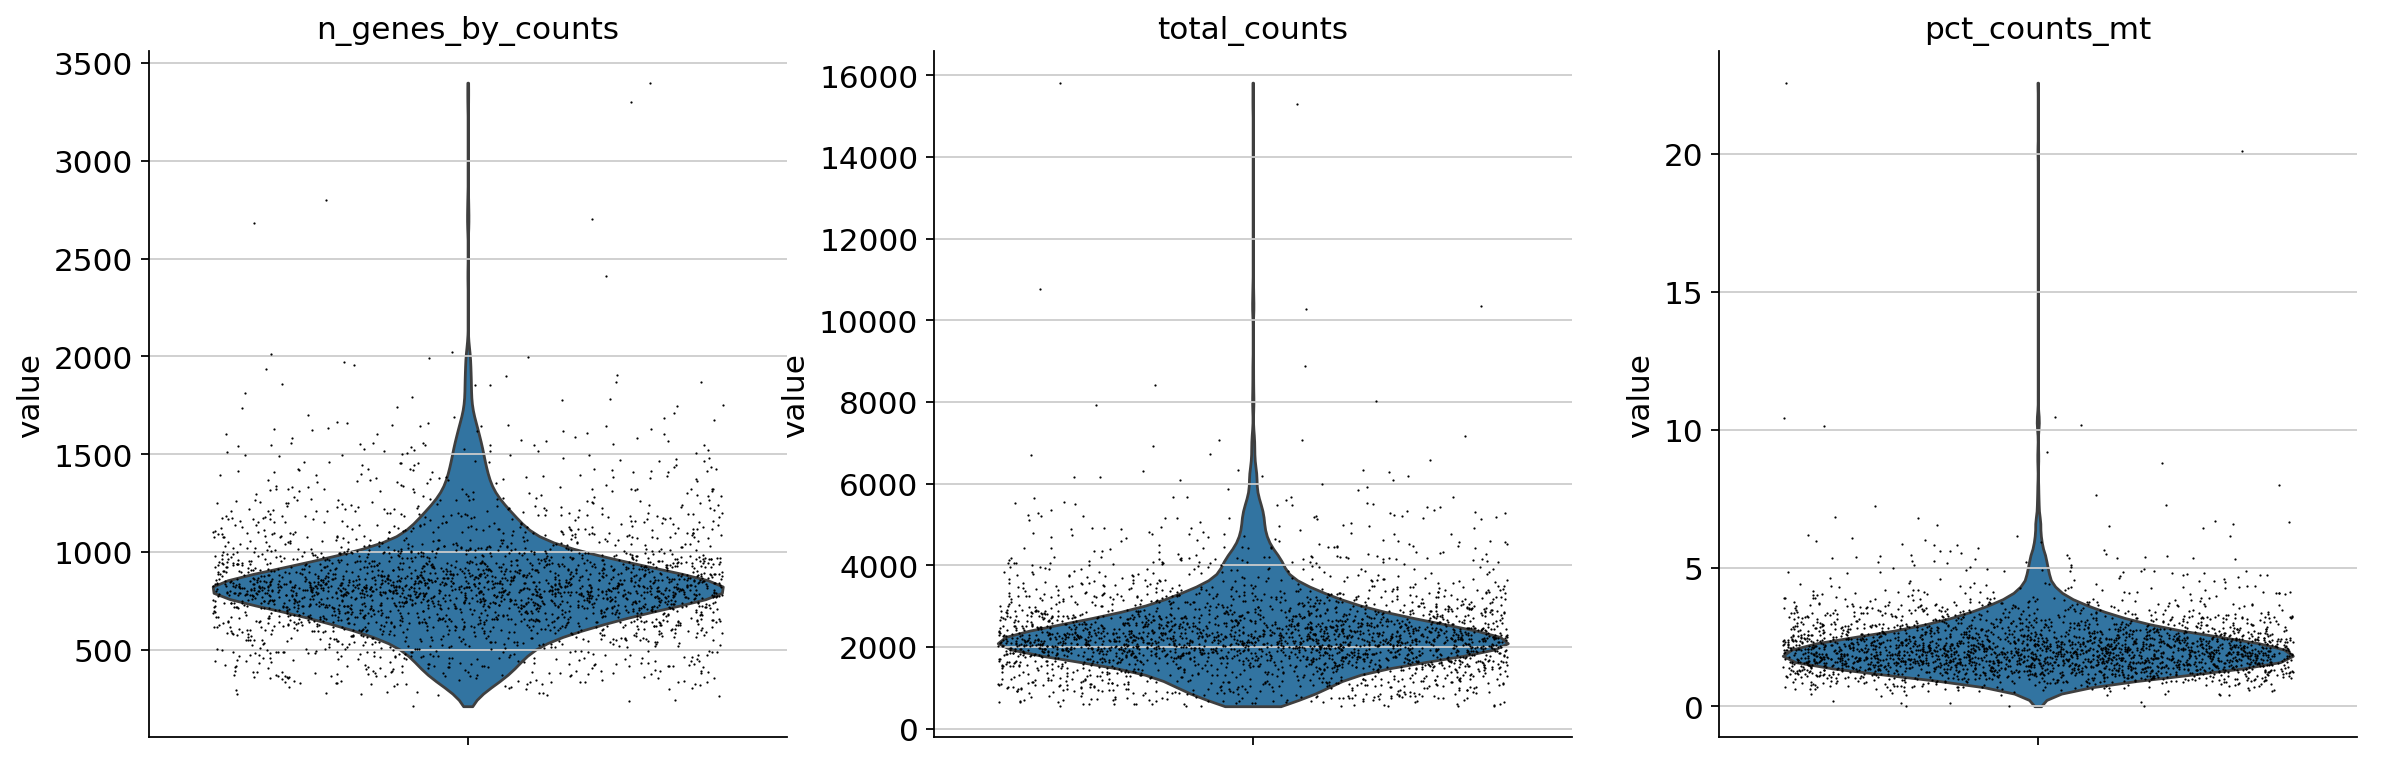

In [11]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

Remove cells that have too many mitochondrial genes expressed or too many total counts:



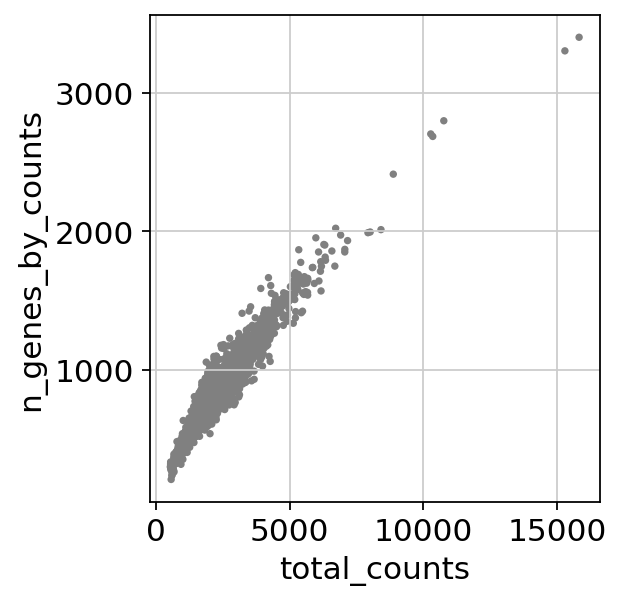

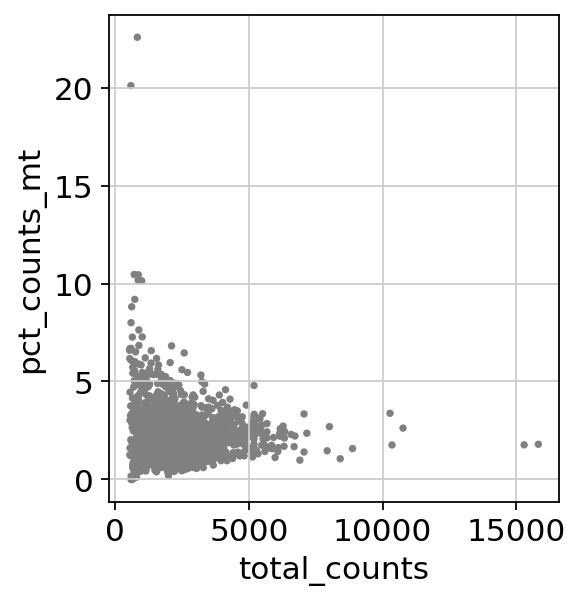

In [12]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')

slicing Annadata:


In [13]:
adata = adata[adata.obs.n_genes_by_counts <2500, :]
adata = adata[adata.obs.pct_counts_mt <5, :]

Total-count normalize (library-size correct) the data matrix X to 10,000 reads per cell, and logarithmize the Data:

In [14]:
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:00)


/home/saif/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [15]:
sc.pp.log1p(adata)

Highly variable gene:

In [16]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


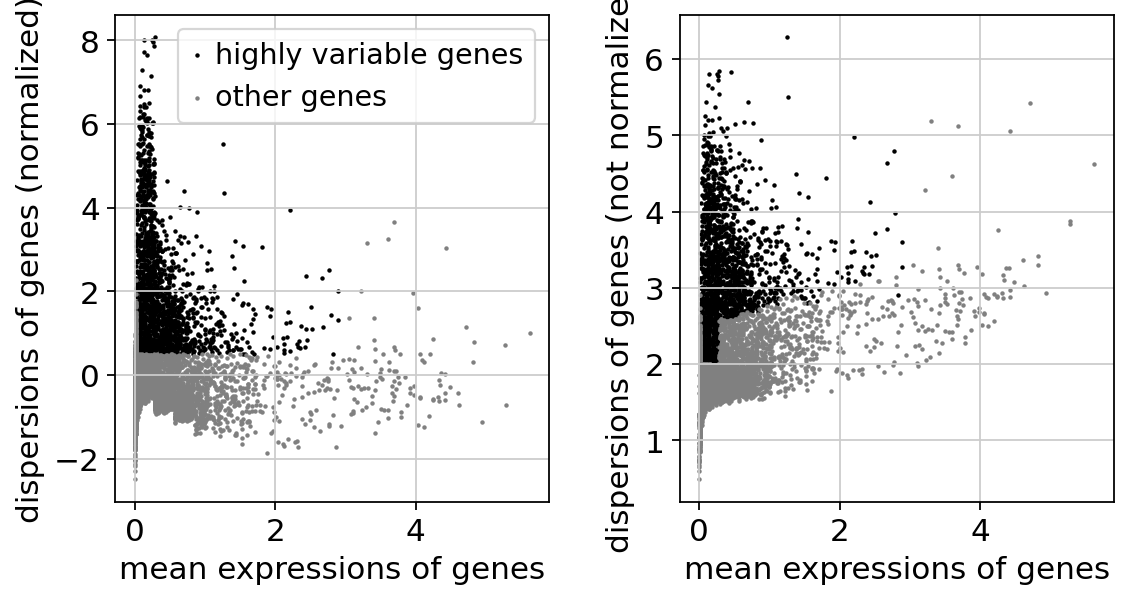

In [17]:
sc.pl.highly_variable_genes(adata)

In [18]:
adata.raw = adata  #.raw attribute of the AnnData object to the normalized and logarithmized raw gene expression

Filtering highly variable gene results:(unnecessary)

In [19]:
adata = adata[:, adata.var.highly_variable]


Regress_out unwanted source of Varitaion:

In [20]:
adata = adata[:, adata.var.highly_variable]

In [21]:
#Scale each gene to unit variance
sc.pp.scale(adata, max_value=10)


... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


/home/saif/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


### Principal component analysis:


In [22]:
sc.tl.pca(adata, svd_solver='arpack')

computing PCA
    with n_comps=50
    finished (0:00:00)


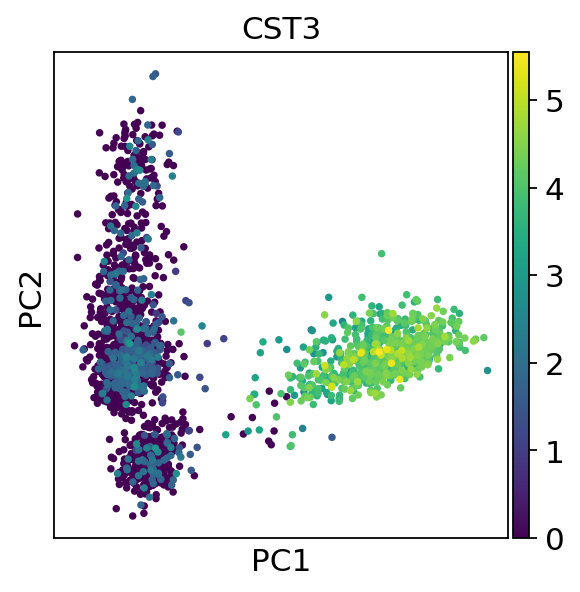

In [23]:
sc.pl.pca(adata, color='CST3')


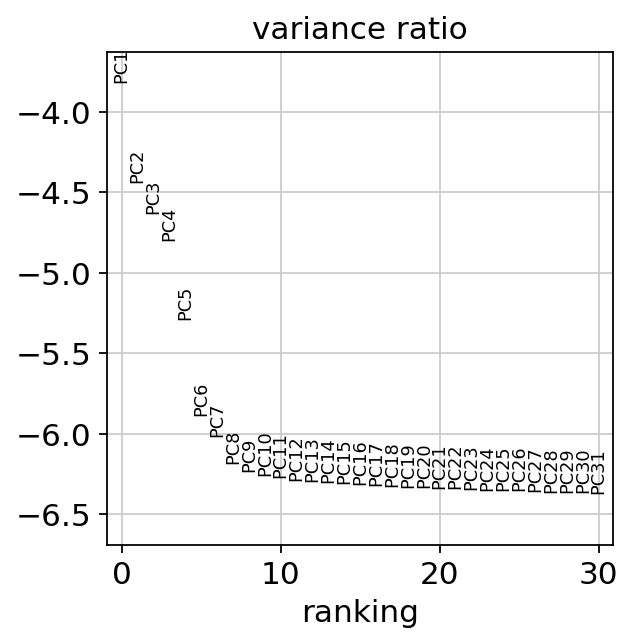

In [24]:
sc.pl.pca_variance_ratio(adata, log=True)

In [25]:
adata.write(results_file) #Save the result.



### Computing and Embedding the Neighborshood Graph:


In [26]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)


In [27]:
sc.tl.umap(adata)


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)


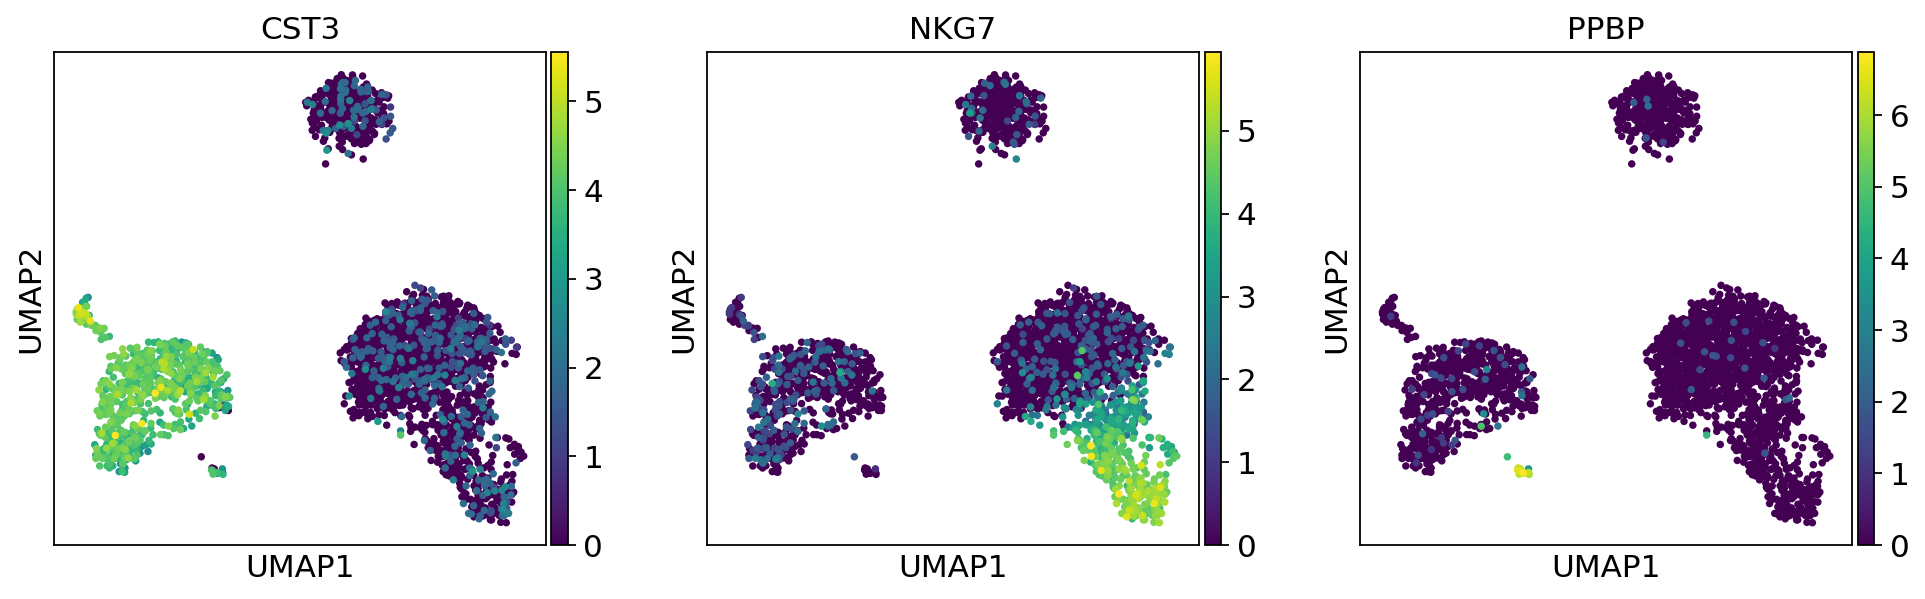

In [28]:
sc.pl.umap(adata, color=['CST3', 'NKG7', 'PPBP'])


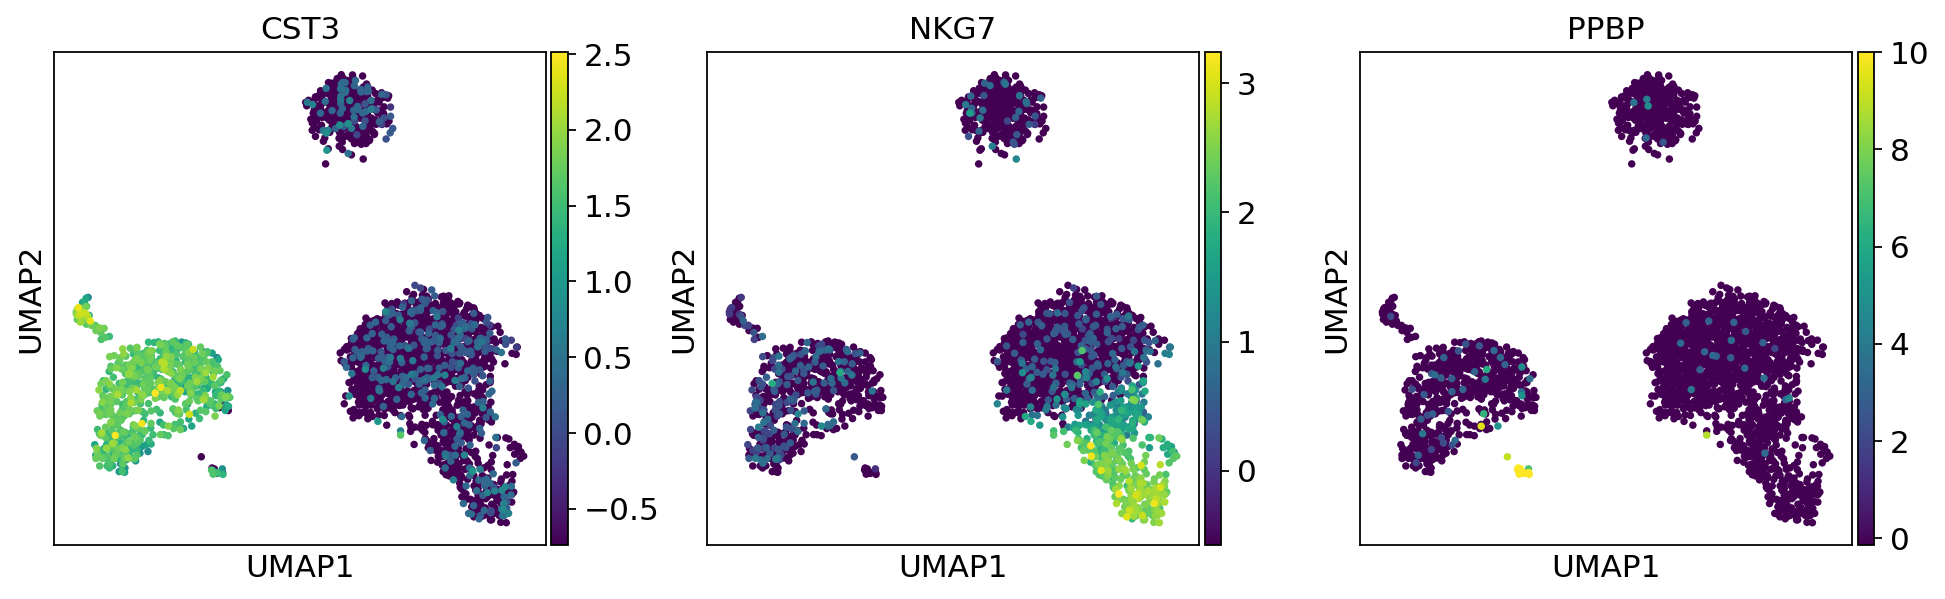

In [29]:
sc.pl.umap(adata, color=['CST3', 'NKG7', 'PPBP'], use_raw=False)


### Clustering the neighborhood graph:


In [30]:
sc.tl.leiden(adata, resolution=0.85)

running Leiden clustering


/tmp/ipykernel_69914/3096991632.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.85)


    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


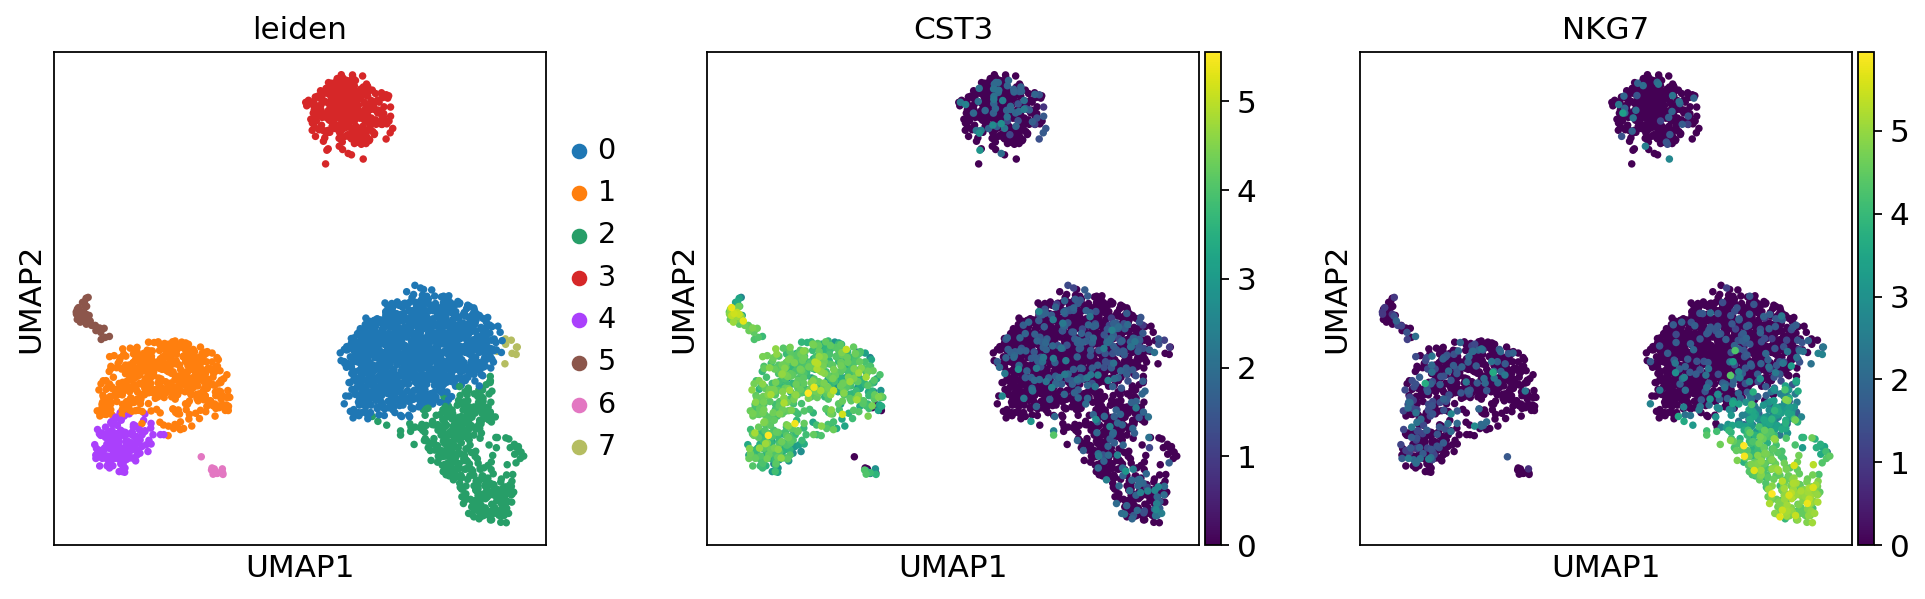

In [31]:
sc.pl.umap(adata, color=['leiden', 'CST3', 'NKG7'])

In [32]:
adata.obs

,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden
AAACATACAACCAC-1,781,779,2419.0,73.0,3.017776,0
AAACATTGAGCTAC-1,1352,1352,4903.0,186.0,3.793596,3
AAACATTGATCAGC-1,1131,1129,3147.0,28.0,0.889736,0
AAACCGTGCTTCCG-1,960,960,2639.0,46.0,1.743085,1
AAACCGTGTATGCG-1,522,521,980.0,12.0,1.224490,2
...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,1155,1153,3459.0,73.0,2.110436,1
TTTCTACTGAGGCA-1,1227,1224,3443.0,32.0,0.929422,3
TTTCTACTTCCTCG-1,622,622,1684.0,37.0,2.197150,3
TTTGCATGAGAGGC-1,454,452,1022.0,21.0,2.054795,3


In [33]:
adata.write(results_file)

### Finding marker genes:

In [34]:
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


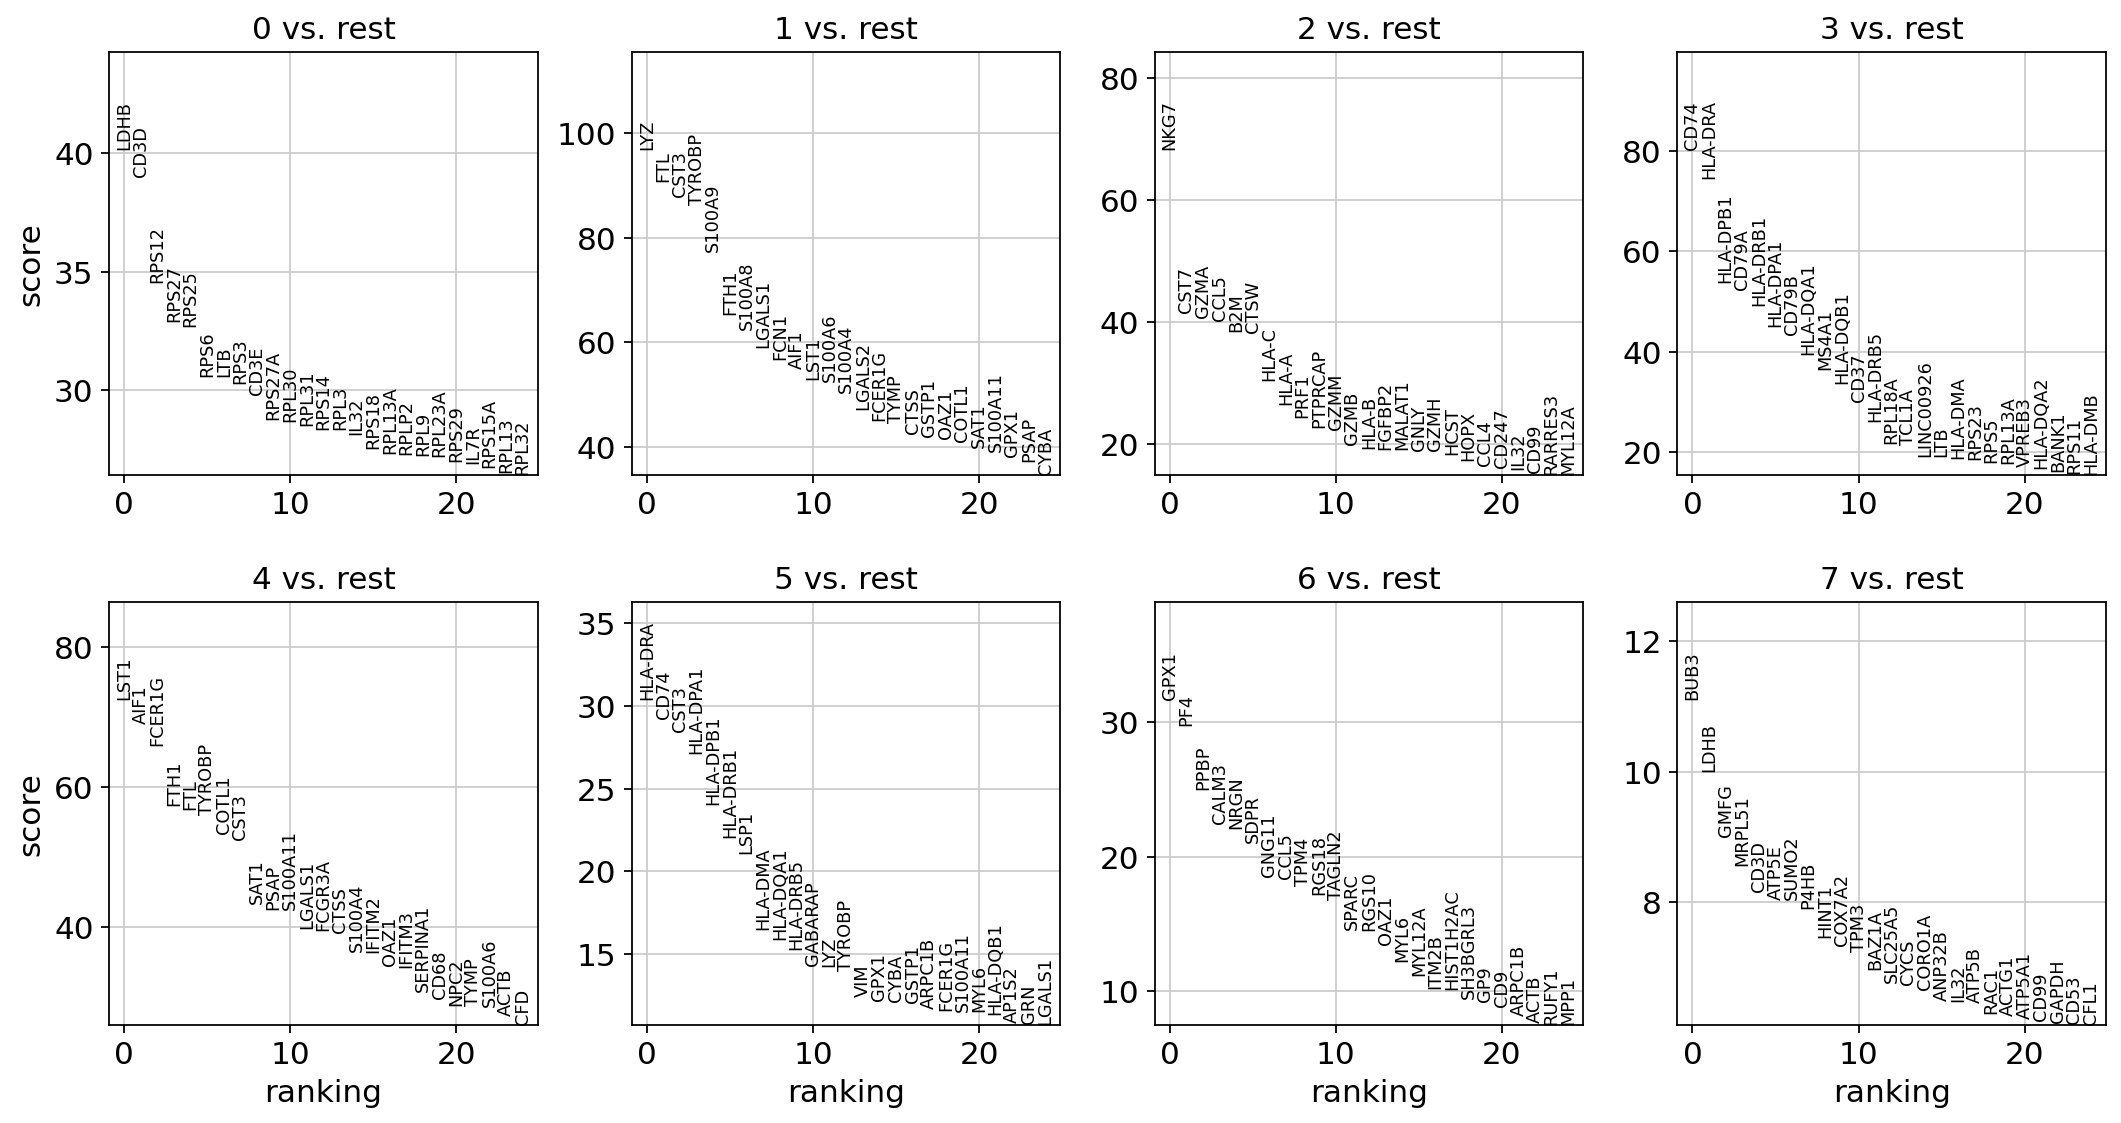

In [35]:
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [36]:
sc.settings.verbosity = 2  # reduce the verbosity


ranking genes
    finished (0:00:01)


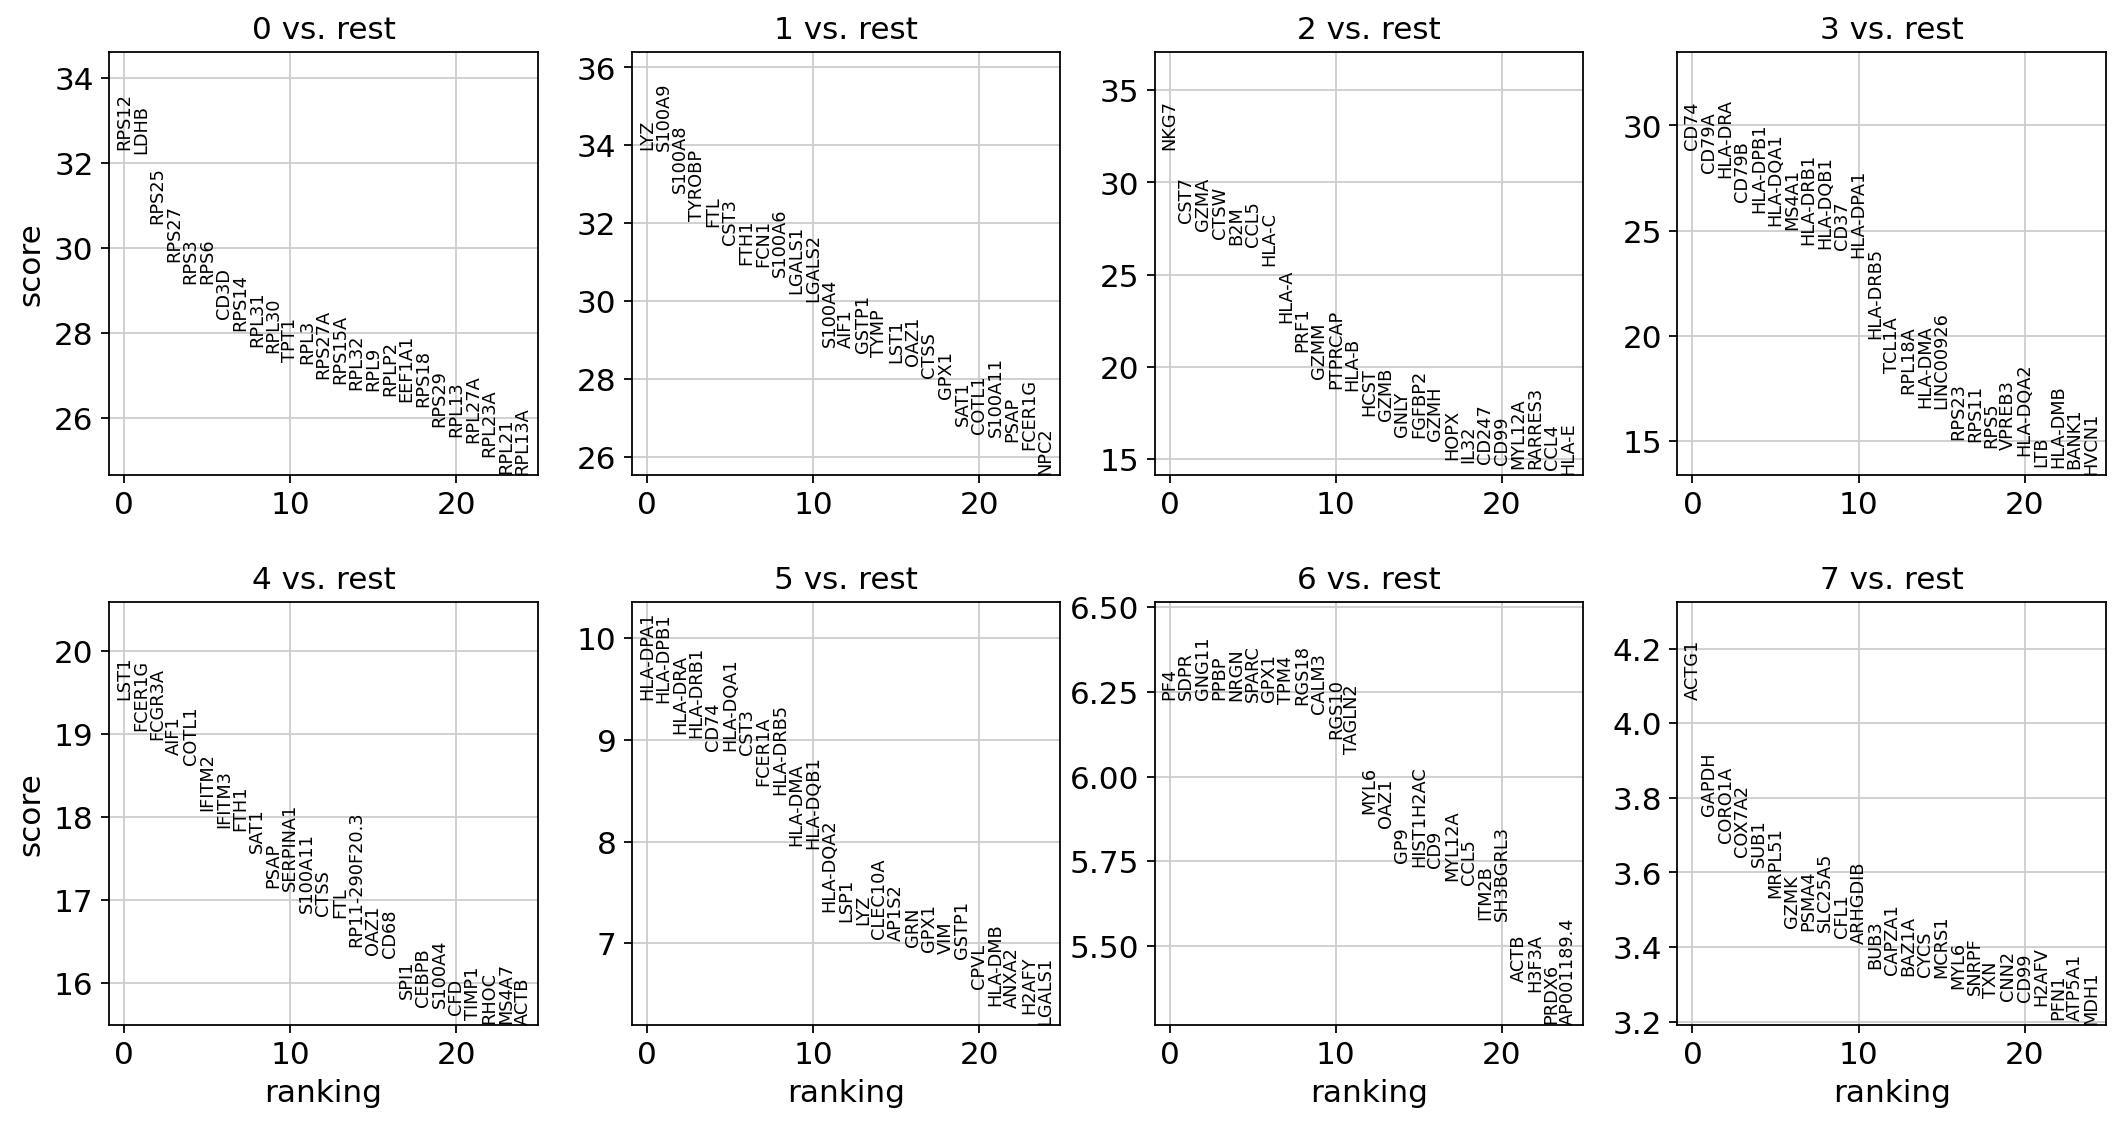

In [37]:
# using wilcoxon 
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [38]:
adata.uns['rank_genes_groups'] ['names'] ['0']

array(['RPS12', 'LDHB', 'RPS25', ..., 'HLA-DRA', 'CYBA', 'CD74'],
      dtype=object)

In [39]:
adata.write(results_file)


ranking genes
    finished (0:00:06)


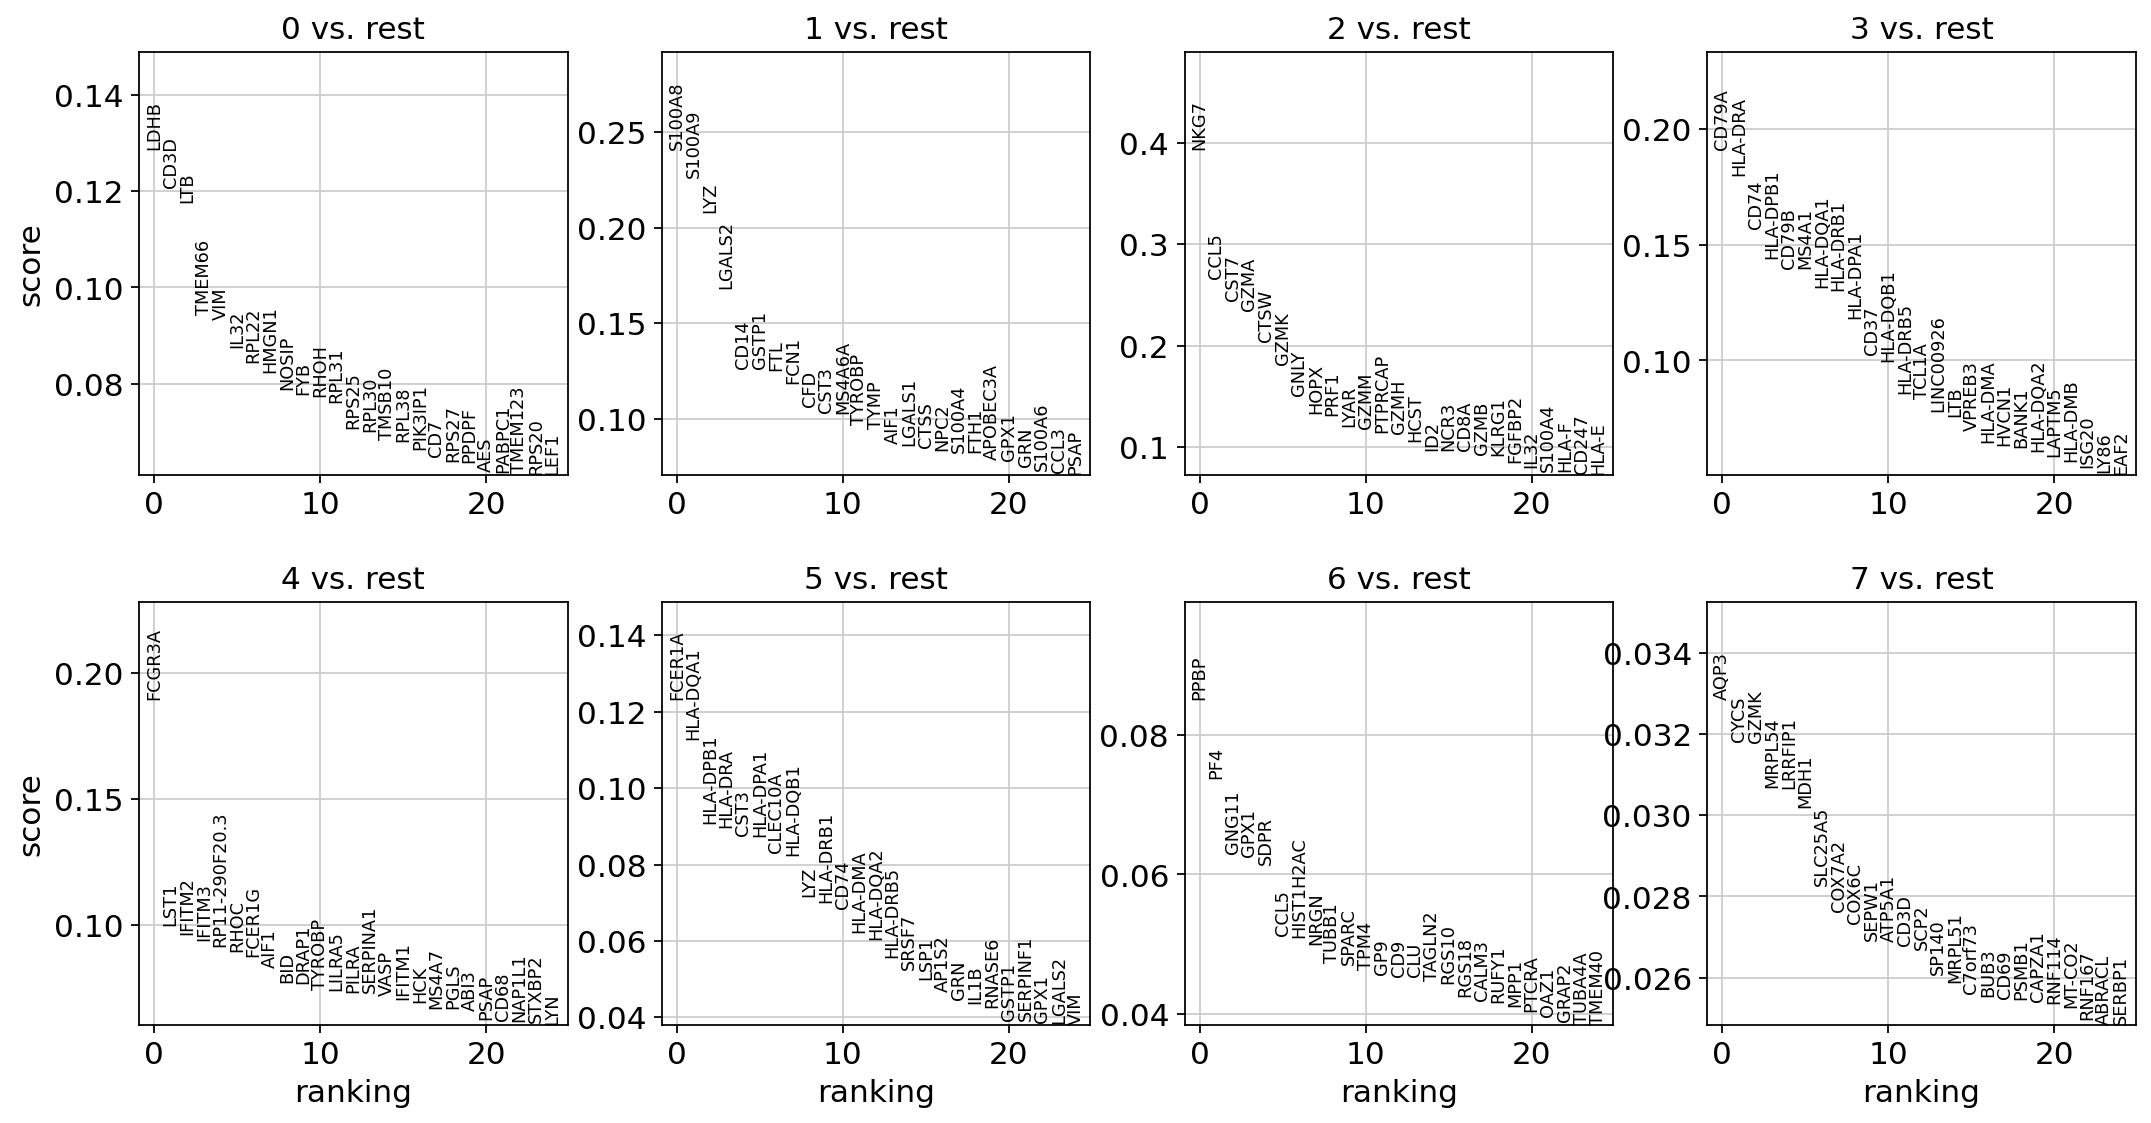

In [40]:
sc.tl.rank_genes_groups(adata, 'leiden', method='logreg')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [41]:
adata = sc.read(results_file)

In [43]:
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(5)

,0,1,2,3,4,5,6,7
0,RPS12,LYZ,NKG7,CD74,LST1,HLA-DPA1,PF4,ACTG1
1,LDHB,S100A9,CST7,CD79A,FCER1G,HLA-DPB1,SDPR,GAPDH
2,RPS25,S100A8,GZMA,HLA-DRA,FCGR3A,HLA-DRA,GNG11,CORO1A
3,RPS27,TYROBP,CTSW,CD79B,AIF1,HLA-DRB1,PPBP,COX7A2
4,RPS3,FTL,B2M,HLA-DPB1,COTL1,CD74,NRGN,SUB1


In [42]:
marker_genes = ['IL7R', 'CD79A', 'MS4A1', 'CD8A', 'CD8B', 'LYZ', 'CD14',
                'LGALS3', 'S100A8', 'GNLY', 'NKG7', 'KLRB1',
                'FCGR3A', 'MS4A7', 'FCER1A', 'CST3', 'PPBP']

Get a table with the scores and groups.

In [44]:
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals']}).head(5)

,0_n,0_p,1_n,1_p,2_n,2_p,3_n,3_p,4_n,4_p,5_n,5_p,6_n,6_p,7_n,7_p
0,RPS12,3.026103e-229,LYZ,7.723581e-252,NKG7,7.374596e-222,CD74,3.576806e-183,LST1,5.544223e-84,HLA-DPA1,5.422417e-21,PF4,4.722886e-10,ACTG1,0.000048
1,LDHB,7.020182e-228,S100A9,2.623281e-251,CST7,1.024136e-170,CD79A,7.554718e-170,FCER1G,7.620642e-81,HLA-DPB1,7.591860e-21,SDPR,4.733899e-10,GAPDH,0.000175
2,RPS25,2.357523e-205,S100A8,1.000638e-235,GZMA,1.828063e-165,HLA-DRA,1.422656e-166,FCGR3A,6.495094e-80,HLA-DRA,1.306768e-19,GNG11,4.733899e-10,CORO1A,0.000232
3,RPS27,7.845436e-194,TYROBP,8.317654e-226,CTSW,2.460361e-160,CD79B,1.120700e-153,AIF1,1.894017e-78,HLA-DRB1,1.865104e-19,PPBP,4.744938e-10,COX7A2,0.000269
4,RPS3,3.437310e-187,FTL,1.732141e-223,B2M,1.562649e-156,HLA-DPB1,1.111071e-147,COTL1,1.910118e-77,CD74,5.853161e-19,NRGN,4.800511e-10,SUB1,0.000300


compare to single cluster.

ranking genes
    finished (0:00:00)


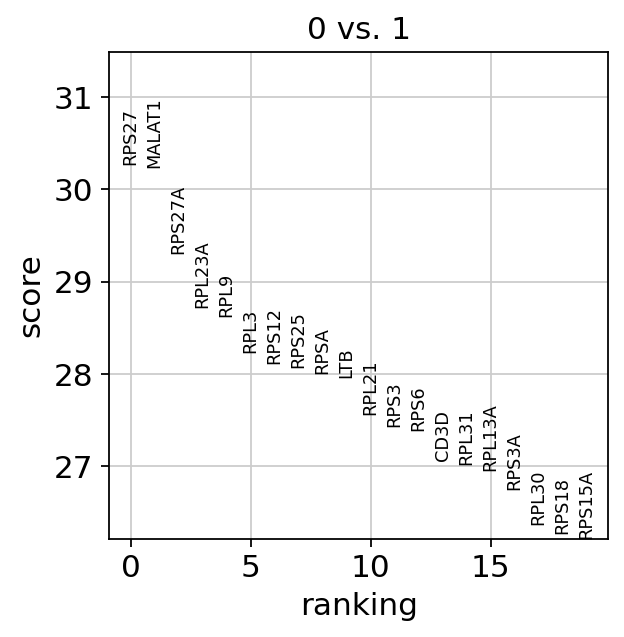

In [45]:
sc.tl.rank_genes_groups(adata, 'leiden', groups=['0'], reference='1', method='wilcoxon')
sc.pl.rank_genes_groups(adata, groups=['0'], n_genes=20)

/home/saif/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/__init__.py:1320: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


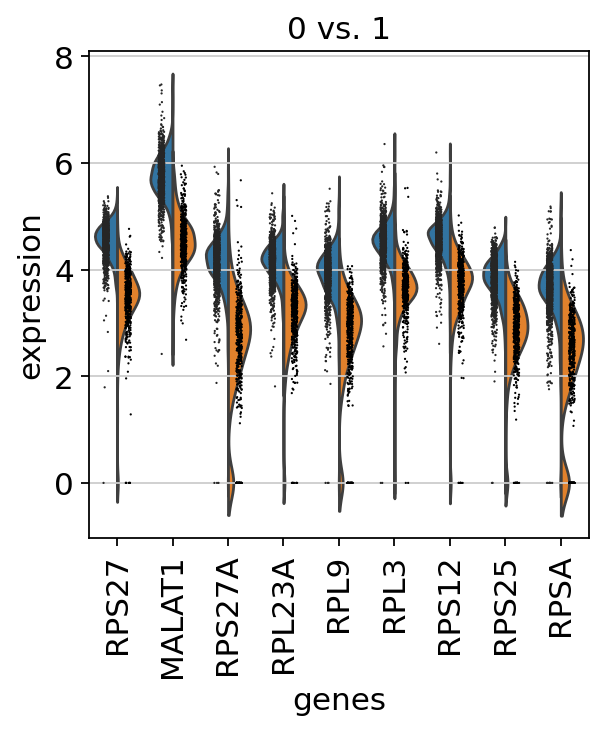

In [46]:
# more deltial about specific group for instance:
sc.pl.rank_genes_groups_violin(adata, groups='0', n_genes=9)

In [47]:
# reload computed differential expression
adata = sc.read(results_file)


/home/saif/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/__init__.py:1320: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


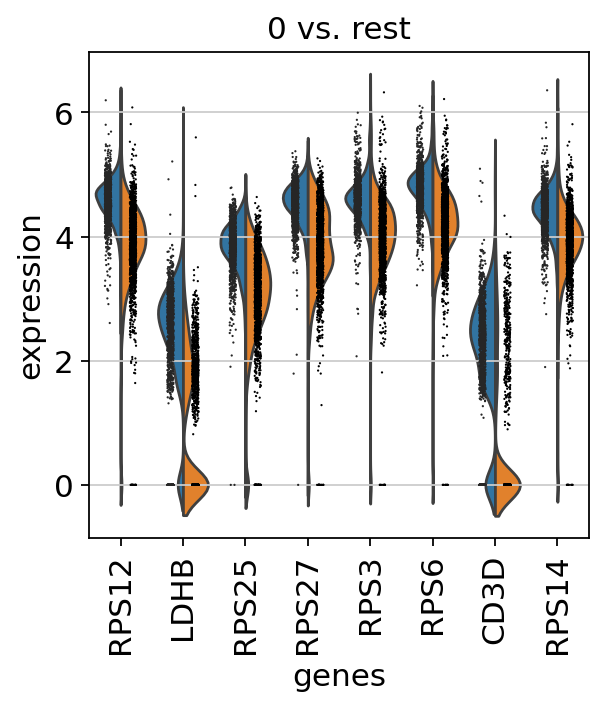

In [48]:
sc.pl.rank_genes_groups_violin(adata, groups='0', n_genes=8)


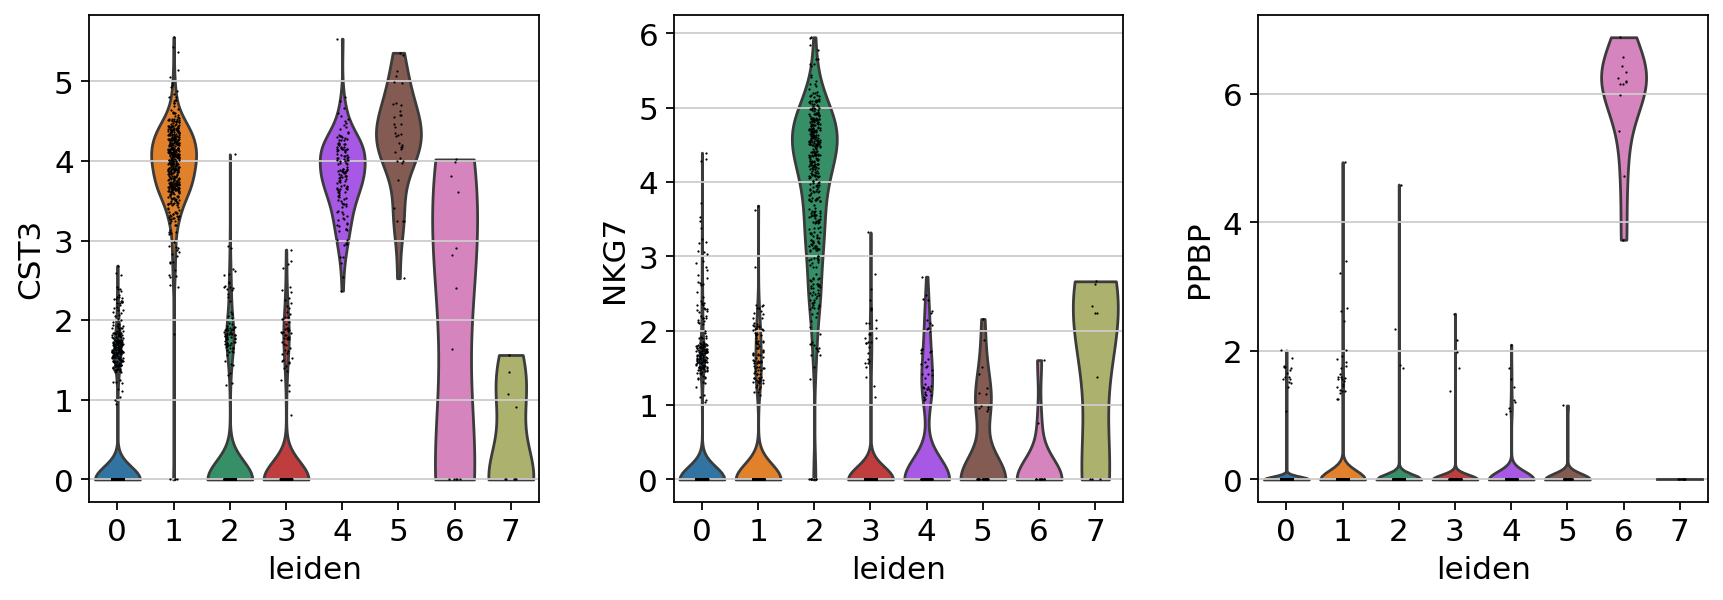

In [49]:
# compare certain gene across groups
sc.pl.violin(adata, ['CST3', 'NKG7', 'PPBP'], groupby='leiden')

mark the cell types.

In [50]:
new_cluster_names = [
    'CD4 T', 'CD14 Monocytes',
    'B', 'CD8 T',
    'NK', 'FCGR3A Monocytes',
    'Dendritic', 'Megakaryocytes']
adata.rename_categories('leiden', new_cluster_names)

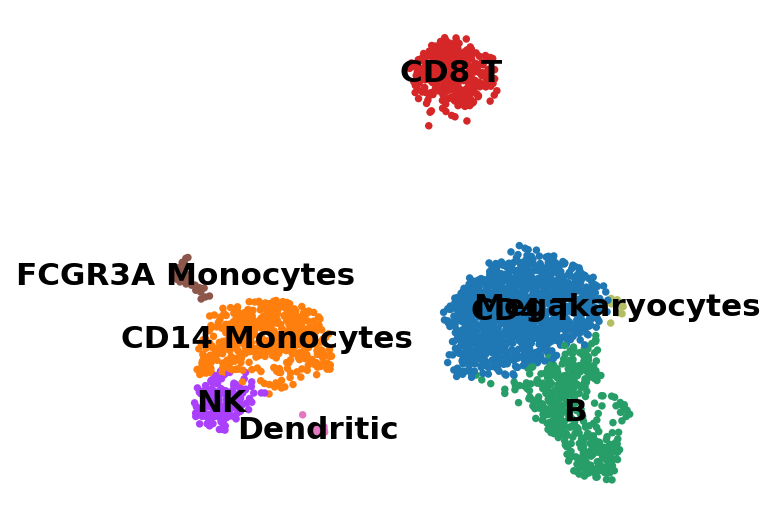

In [51]:
sc.pl.umap(adata, color='leiden', legend_loc='on data', title='', frameon=False, save='.pdf')


In [52]:
adata




AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

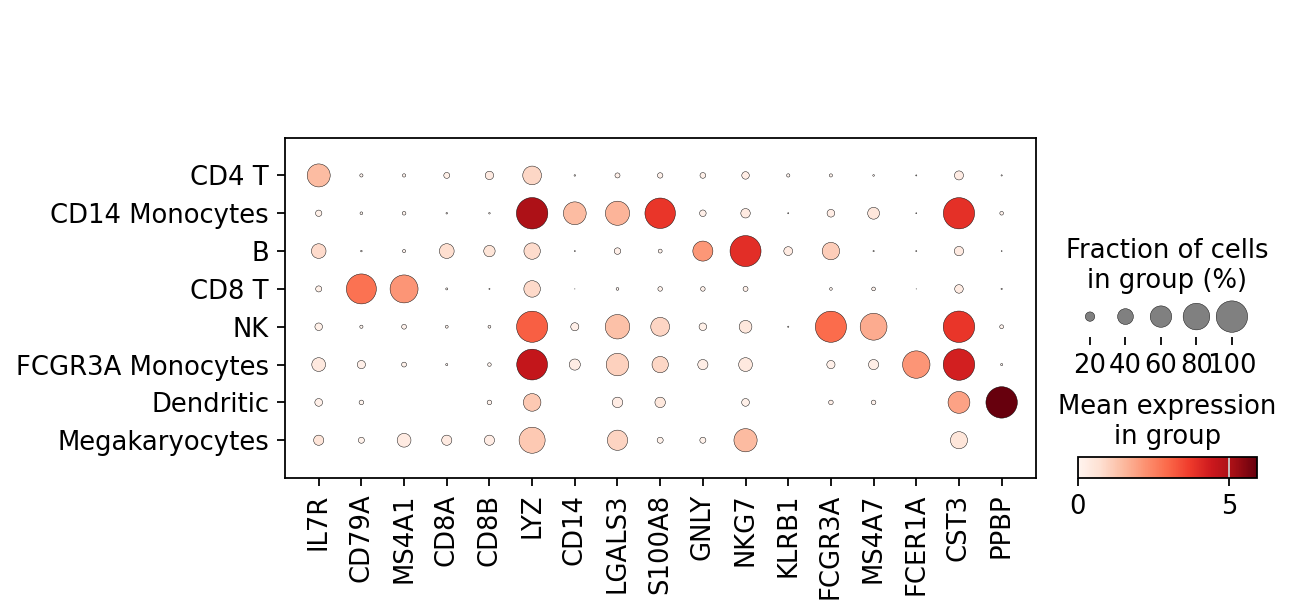

In [53]:
sc.pl.dotplot(adata, marker_genes, groupby='leiden');


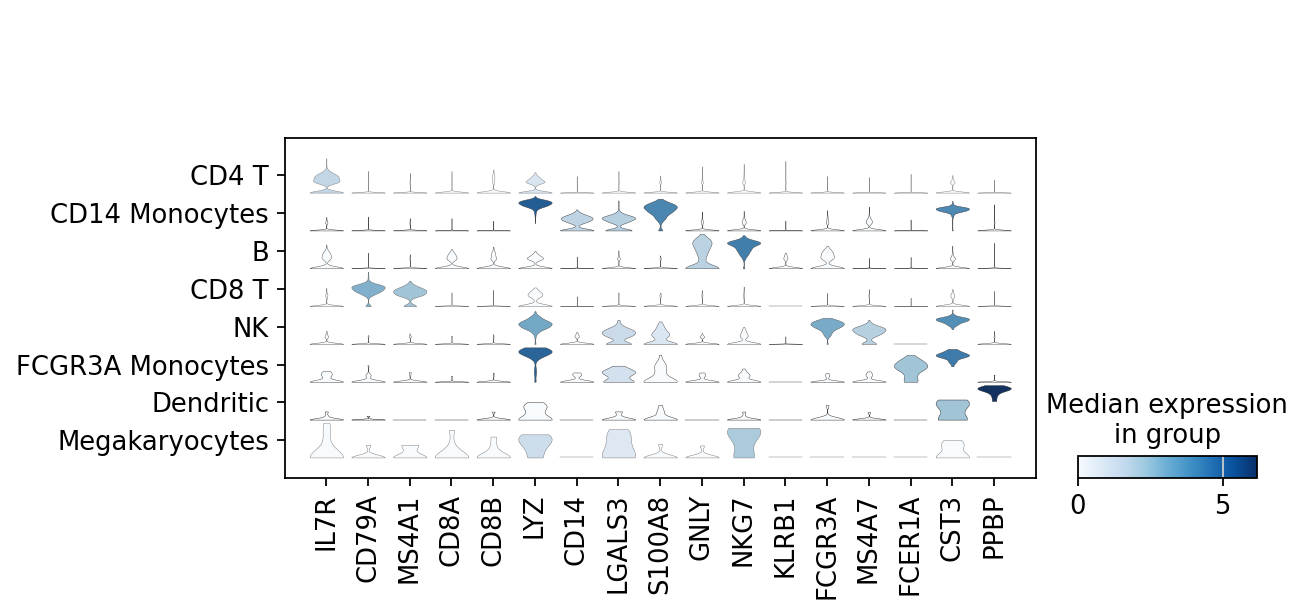

In [54]:
sc.pl.stacked_violin(adata, marker_genes, groupby='leiden')


In [55]:
adata.write(results_file, compression='gzip')